Processed 10/50 pairs; valid results: 10
Processed 20/50 pairs; valid results: 20
Processed 30/50 pairs; valid results: 30
Processed 40/50 pairs; valid results: 40
Processed 50/50 pairs; valid results: 50

Final results (top 10):
        pair ticker_1 ticker_2    mi_ksg  avg_adf_pvalue
0     RSG-WM      RSG       WM  3.300492        0.335722
1       MA-V       MA        V  3.109881        0.129395
2  CDNS-SNPS     CDNS     SNPS  3.054013        0.324811
3    AJG-BRO      AJG      BRO  3.050661        0.445539
4   AJG-MRSH      AJG     MRSH  3.007829        0.307993
5    AJG-RSG      AJG      RSG  2.977478        0.173772
6   MCO-SPGI      MCO     SPGI  2.930191        0.291913
7   AJG-CTAS      AJG     CTAS  2.929631        0.278742
8  MSFT-NVDA     MSFT     NVDA  2.919262        0.373354
9   CTAS-RSG     CTAS      RSG  2.900486        0.314966


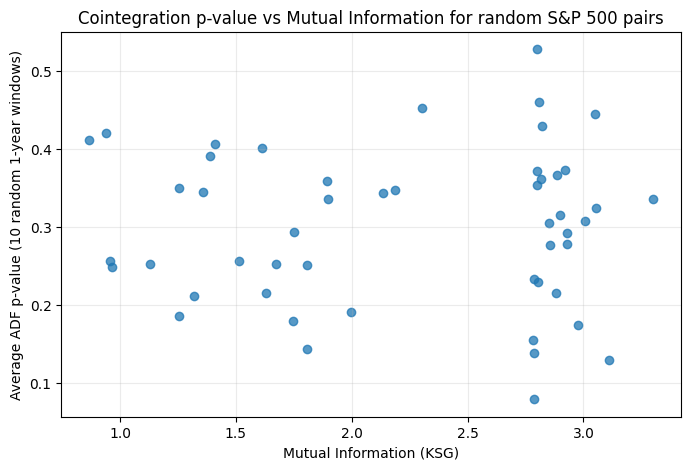

In [20]:
import random
from itertools import combinations

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.special import digamma
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.feature_selection import mutual_info_regression


# -----------------------------
# User parameters
# -----------------------------
TICKERS_FILE = r"G:\Mi unidad\2026\Tesis\Códigos\Data\tickers\sp500_tickers_All.txt"
START_DATE = "2015-01-01"
END_DATE = "2026-01-01"
N_PAIRS = 50                 # Number of random pairs to evaluate for the MI vs p-value scatter
N_WINDOWS = 10               # Number of random 1-year windows per pair
WINDOW_DAYS = 252            # 1-year window length in days
K_KSG = 3                    # k-nearest neighbors for KSG
MIN_POINTS_WINDOW = 20       # Minimum points needed in each 1-year window for ADF on residuals
SEED = 43                    # Reproducibility


# -----------------------------
# Helpers
# -----------------------------
def read_tickers(path: str) -> list[str]:
    with open(path, "r", encoding="utf-8") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    # Convert Berkshire-like symbols from BRK.B to BRK-B for Yahoo Finance compatibility.
    tickers = [t.replace(".", "-") for t in lines]
    # Keep order, remove duplicates
    return list(dict.fromkeys(tickers))


def ksg_mi_continuous(x: np.ndarray, y: np.ndarray, k: int = 3) -> float:
    """
    KSG mutual information estimator (Kraskov-Stogbauer-Grassberger, estimator I)
    for two continuous 1D variables x and y.
    """
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=float).reshape(-1, 1)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length")
    
    #Calculate mutual information in both directions and average to get a symmetric estimate.
    # Reshape X for sklearn's expected feature matrix format
    X = x.reshape(-1, 1)
    Y = y.reshape(-1, 1)
    
    # KSG estimation. We use a fixed random_state because the algorithm 
    # adds a microscopic jitter (~1e-10) to break exact duplicate ties.
    mi_xy = mutual_info_regression(X, y.ravel(), n_neighbors=k, random_state=42)[0]
    
    # KSG is theoretically symmetric, but finite-sample k-NN searches can 
    # induce microscopic asymmetries. We enforce strict physical symmetry.
    mi_yx = mutual_info_regression(Y, x.ravel(), n_neighbors=k, random_state=42)[0]
    mi_symmetric = (mi_xy + mi_yx) / 2.0
    return mi_symmetric


def average_adf_pvalue_cointegration(
    prices_a: pd.Series,
    prices_b: pd.Series,
    n_windows: int = 10,
    window_days: int = 365,
    min_points: int = 120,
    rng: random.Random | None = None,
) -> float:
    """
    Engle-Granger style cointegration proxy:
    - Regress y on x inside each random 1-year window
    - Run ADF on residuals
    - Return average p-value across sampled windows
    """
    if rng is None:
        rng = random.Random()

    df = pd.concat([prices_a, prices_b], axis=1).dropna()
    if df.empty:
        return np.nan

    df.columns = ["a", "b"]
    dates = df.index

    # Feasible start dates that allow a full 1-year window.
    max_start = dates.max() - pd.Timedelta(days=window_days)
    candidate_starts = dates[dates <= max_start]
    if len(candidate_starts) == 0:
        return np.nan

    pvals = []
    for _ in range(n_windows):
        start = candidate_starts[rng.randrange(len(candidate_starts))]
        end = start + pd.Timedelta(days=window_days)
        sub = df.loc[(df.index >= start) & (df.index <= end)]

        if len(sub) < min_points:
            continue

        x = sm.add_constant(sub["a"].values)
        y = sub["b"].values

        try:
            model = sm.OLS(y, x).fit()
            resid = model.resid
            adf_stat = adfuller(resid, autolag="AIC")
            pvals.append(adf_stat[1])
        except Exception:
            continue

    if not pvals:
        return np.nan
    return float(np.mean(pvals))


def get_log_prices_for_pair(pair: tuple[str, str], start: str, end: str) -> pd.DataFrame | None:
    t1, t2 = pair
    data = yf.download([t1, t2], start=start, end=end, auto_adjust=True, progress=False)

    if data.empty:
        return None

    # Support both single-index and multi-index column formats from yfinance.
    if isinstance(data.columns, pd.MultiIndex):
        close = data.get("Close")
        if close is None:
            close = data.get("Adj Close")
    else:
        if "Close" in data.columns:
            close = data[["Close"]]
            close.columns = [t1]
        elif "Adj Close" in data.columns:
            close = data[["Adj Close"]]
            close.columns = [t1]
        else:
            return None

    if close is None or close.empty:
        return None

    # Ensure both tickers exist as columns.
    missing = [t for t in [t1, t2] if t not in close.columns]
    if missing:
        return None

    close = close[[t1, t2]].dropna()
    if len(close) < 300:
        return None

    return np.log(close)


# -----------------------------
# Main workflow
# -----------------------------
rng = random.Random(SEED)
np.random.seed(SEED)

# tickers = ['ABV', 'EQR','MET', 'PRU', 'FITB', 'RF', 'UDR']  # For testing, use a small set of known tickers
tickers = read_tickers(TICKERS_FILE)
all_pairs = list(combinations(tickers, 2))  # For testing, use a small set of known pairs
rng.shuffle(all_pairs)
shuffled_pairs = all_pairs[:N_PAIRS//2]
selected_pairs = [('RSG', 'WM'), ('MA', 'V'), ('CDNS', 'SNPS'), ('AJG', 'BRO'), ('AJG', 'MRSH'), ('AJG', 'RSG'), ('MCO', 'SPGI'), ('AJG', 'CTAS'), ('MSFT', 'NVDA'), ('CTAS', 'RSG'), ('BRO', 'MRSH'), ('AJG', 'PGR'), ('AJG', 'AON'), ('CTAS', 'MSI'), ('BRO', 'RSG'), ('BRO', 'CTAS'), ('KLAC', 'LRCX'), ('AJG', 'MSI'), ('CDNS', 'MSFT'), ('MSI', 'RSG'), ('AMAT', 'LRCX'), ('AJG', 'WM'), ('CTAS', 'PGR'), ('CPRT', 'CTAS'), ('CTAS', 'MSFT'), ('AJG', 'MSFT'), ('CTAS', 'FICO'), ('CTAS', 'WM'), ('MSFT', 'SNPS'), ('AVGO', 'NVDA'), ('CPRT', 'MSFT'), ('MSI', 'WM'), ('CTAS', 'MRSH'), ('MRSH', 'RSG'), ('AJG', 'TT'), ('INTU', 'MSFT'), ('PGR', 'RSG'), ('AZO', 'ORLY'), ('AJG', 'FICO'), ('AJG', 'CPRT'), ('CTAS', 'SNPS'), ('GOOG', 'MSFT'), ('MSFT', 'RSG'), ('AMAT', 'KLAC'), ('MSFT', 'MSI'), ('BRO', 'MSFT'), ('CDNS', 'CTAS'), ('AVGO', 'KLAC'), ('AON', 'MRSH'), ('ETN', 'PH')]
#Concatenate the random pairs with the selected pairs
# Concatenate half of manual pairs with random pairs (as Python lists, not NumPy)
selected_pairs = (selected_pairs[: N_PAIRS // 2] + shuffled_pairs)[:N_PAIRS]

results = []

for i, pair in enumerate(selected_pairs, start=1):
    log_prices = get_log_prices_for_pair(pair, START_DATE, END_DATE)
    if log_prices is None:
        continue

    s1, s2 = pair
    # Calculate log-returns for both tickers in the pair

    x = log_prices[s1].values
    y = log_prices[s2].values

    mi_value = ksg_mi_continuous(x, y, k=K_KSG)
    avg_pvalue = average_adf_pvalue_cointegration(
        log_prices[s1],
        log_prices[s2],
        n_windows=N_WINDOWS,
        window_days=WINDOW_DAYS,
        min_points=MIN_POINTS_WINDOW,
        rng=rng,
    )

    if np.isfinite(mi_value) and np.isfinite(avg_pvalue):
        results.append(
            {
                "pair": f"{s1}-{s2}",
                "ticker_1": s1,
                "ticker_2": s2,
                "mi_ksg": mi_value,
                "avg_adf_pvalue": avg_pvalue,
            }
        )

    if i % 10 == 0:
        print(f"Processed {i}/{len(selected_pairs)} pairs; valid results: {len(results)}")

res_df = pd.DataFrame(results).sort_values("mi_ksg", ascending=False).reset_index(drop=True)
print("\nFinal results (top 10):")
print(res_df.head(10))

# -----------------------------
# Plot: p-value as function of MI
# -----------------------------
if not res_df.empty:
    plt.figure(figsize=(8, 5))
    plt.scatter(res_df["mi_ksg"], res_df["avg_adf_pvalue"], alpha=0.75)
    plt.xlabel("Mutual Information (KSG)")
    plt.ylabel("Average ADF p-value (10 random 1-year windows)")
    plt.title("Cointegration p-value vs Mutual Information for random S&P 500 pairs")
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("No valid pair results were generated. Try increasing N_PAIRS or checking ticker availability.")

# Optional: save results
# res_df.to_csv("mi_vs_cointegration_sp500_pairs.csv", index=False)


In [ ]:
    box_stats = [
        {
            "med": row["adf_q50"],
            "q1": row["adf_q25"],
            "q3": row["adf_q75"],
            "whislo": row["adf_q10"],
            "whishi": row["adf_q90"],
            "fliers": [],
            "label": row["pair"],
        }
        for _, row in plot_df.iterrows()
    ]

    positions = plot_df["mi_value"].values
    if len(positions) > 1:
        sorted_unique = np.sort(np.unique(positions))
        min_gap = np.min(np.diff(sorted_unique)) if len(sorted_unique) > 1 else 0.01
        width = max(min_gap * 0.5, 0.002)
    else:
        width = 0.01

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bxp(box_stats, positions=positions, widths=width, showfliers=False, manage_ticks=False)
    ax.set_xlabel("Mutual Information from CSV")
    ax.set_ylabel("ADF test statistic distribution (Q10-Q90, box Q25-Q75)")
    ax.set_title("Cointegration ADF statistic quantiles vs MI-equidistant selected pairs")
    ax.grid(alpha=0.25)
    plt.show()

Selected 20 pairs from 20 MI bins over [MI_min, MI_max].
Processed 5/20 selected pairs; valid results: 3
Processed 10/20 selected pairs; valid results: 8
Processed 15/20 selected pairs; valid results: 13
Processed 20/20 selected pairs; valid results: 18

Final results (top 10 by MI):
         pair ticker_1 ticker_2  mi_value   adf_q10   adf_q25   adf_q50  \
0    HSY-SOLV      HSY     SOLV  0.412846 -3.005852 -2.865560 -2.559118   
1    CRM-KVUE      CRM     KVUE  0.578376 -2.548300 -2.325740 -1.944387   
2     CPB-SNA      CPB      SNA  0.743610 -3.546339 -2.974093 -2.303729   
3     FDX-PPG      FDX      PPG  0.908861 -3.131902 -2.730940 -2.171771   
4    BEN-MPWR      BEN     MPWR  1.074093 -3.001787 -2.627006 -1.995795   
5       J-TFC        J      TFC  1.239359 -3.237311 -2.775316 -2.094539   
6    MDLZ-TER     MDLZ      TER  1.404617 -2.973484 -2.437709 -1.838194   
7      CF-TPL       CF      TPL  1.569845 -2.632020 -2.246420 -1.842514   
8    CRM-ODFL      CRM     ODFL  1.73509

KeyError: 'p_q50'

Selected 20 pairs from 20 MI bins over [MI_min, MI_max].
Processed 5/20 selected pairs; valid results: 3
Processed 10/20 selected pairs; valid results: 8
Processed 15/20 selected pairs; valid results: 13
Processed 20/20 selected pairs; valid results: 18

Final results (top 10 by MI):
         pair ticker_1 ticker_2  mi_value     p_q10     p_q25     p_q50  \
0    HSY-SOLV      HSY     SOLV  0.412846  0.034351  0.049502  0.101748   
1    CRM-KVUE      CRM     KVUE  0.578376  0.104160  0.163801  0.311477   
2     CPB-SNA      CPB      SNA  0.743610  0.006874  0.037386  0.170768   
3     FDX-PPG      FDX      PPG  0.908861  0.024281  0.068836  0.216650   
4    BEN-MPWR      BEN     MPWR  1.074093  0.034728  0.087543  0.288420   
5       J-TFC        J      TFC  1.239359  0.017924  0.061887  0.246716   
6    MDLZ-TER     MDLZ      TER  1.404617  0.037446  0.131375  0.361671   
7      CF-TPL       CF      TPL  1.569845  0.086558  0.189831  0.359568   
8    CRM-ODFL      CRM     ODFL  1.73509

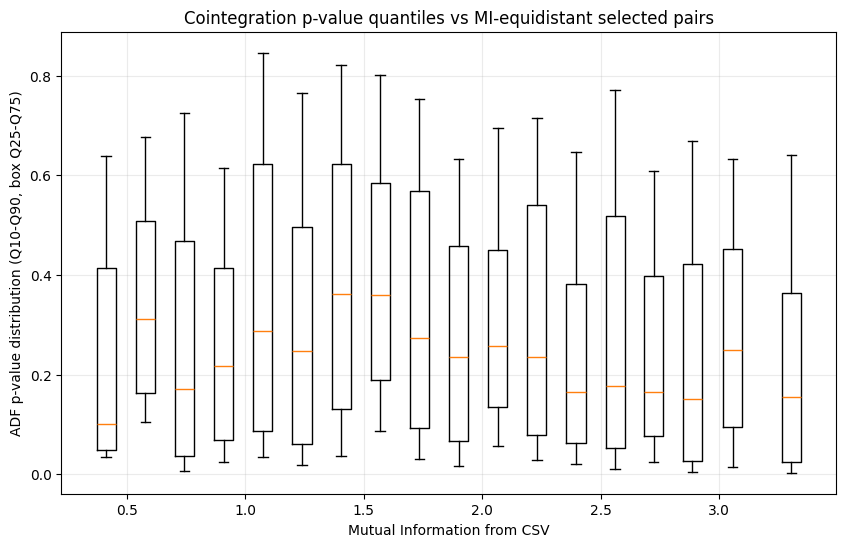

In [ ]:
    box_stats = [
        {
            "med": row["adf_q50"],
            "q1": row["adf_q25"],
            "q3": row["adf_q75"],
            "whislo": row["adf_q10"],
            "whishi": row["adf_q90"],
            "fliers": [],
            "label": row["pair"],
        }
        for _, row in plot_df.iterrows()
    ]

    positions = plot_df["mi_value"].values
    if len(positions) > 1:
        sorted_unique = np.sort(np.unique(positions))
        min_gap = np.min(np.diff(sorted_unique)) if len(sorted_unique) > 1 else 0.01
        width = max(min_gap * 0.5, 0.002)
    else:
        width = 0.01

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bxp(box_stats, positions=positions, widths=width, showfliers=False, manage_ticks=False)
    ax.set_xlabel("Mutual Information from CSV")
    ax.set_ylabel("ADF test statistic distribution (Q10-Q90, box Q25-Q75)")
    ax.set_title("Cointegration ADF statistic quantiles vs MI-equidistant selected pairs")
    ax.grid(alpha=0.25)
    plt.show()

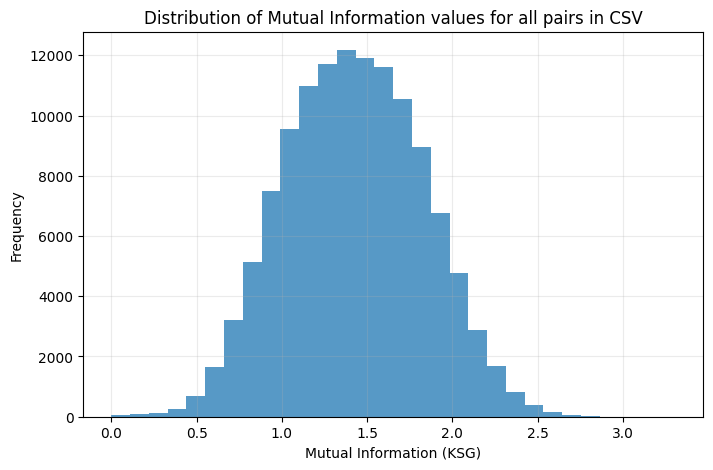

In [10]:
#Plot a figure
plt.figure(figsize=(8, 5))
plt.hist(pairs_df["mi_value"], bins=30, alpha=0.75)
plt.xlabel("Mutual Information (KSG)")
plt.ylabel("Frequency")
plt.title("Distribution of Mutual Information values for all pairs in CSV")
plt.grid(alpha=0.25)
plt.show()